# Plots

## Boxplots

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load data with pseudo labels
data_path = Path("../outputs/hrv_windows_final.csv")
df = pd.read_csv(data_path)

print(f"Data shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print("\nPseudo label distribution:")
print(df["pseudo_label_smoothed"].value_counts().sort_index())

Data shape: (2541, 31)

Columns: ['dataset', 'subject_id', 'trial_id', 'window_index', 'window_start_sec', 'window_end_sec', 'sampling_rate', 'mean_rr', 'mean_hr', 'sdnn', 'rmssd', 'nn50', 'pnn50', 'cv_rr', 'mean_rr_znorm', 'mean_hr_znorm', 'sdnn_znorm', 'rmssd_znorm', 'nn50_znorm', 'pnn50_znorm', 'cv_rr_znorm', 'cluster_kmeans', 'pseudo_kss_kmeans', 'pseudo_label_kmeans', 'cluster_gmm', 'pseudo_kss_gmm', 'pseudo_label_gmm', 'pseudo_kss', 'pseudo_label', 'pseudo_kss_smoothed', 'pseudo_label_smoothed']

Pseudo label distribution:
pseudo_label_smoothed
0    1616
1     925
Name: count, dtype: int64


In [22]:
# Identify HRV feature columns (exclude metadata and labels)
exclude_cols = {
    "dataset",
    "subject_id",
    "trial_id",
    "window_index",
    "window_start_sec",
    "window_end_sec",
    "sampling_rate",
    "mean_rr",
    "mean_hr",
    "sdnn",
    "rmssd",
    "nn50",
    "pnn50",
    "cv_rr",
    "cluster_kmeans",
    "pseudo_kss_kmeans",
    "pseudo_label_kmeans",
    "cluster_gmm",
    "pseudo_kss_gmm",
    "pseudo_label_gmm",
    "pseudo_kss",
    "pseudo_label",
    "pseudo_kss_smoothed",
    "pseudo_label_smoothed",
}
hrv_features = [col for col in df.columns if col not in exclude_cols]

print(f"HRV Features ({len(hrv_features)}): {hrv_features}\n")

HRV Features (7): ['mean_rr_znorm', 'mean_hr_znorm', 'sdnn_znorm', 'rmssd_znorm', 'nn50_znorm', 'pnn50_znorm', 'cv_rr_znorm']



C:\Users\moris\AppData\Local\Temp\ipykernel_13304\3727257404.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pseudo_label_smoothed', y=feature, ax=ax, palette='Set2')
C:\Users\moris\AppData\Local\Temp\ipykernel_13304\3727257404.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pseudo_label_smoothed', y=feature, ax=ax, palette='Set2')
C:\Users\moris\AppData\Local\Temp\ipykernel_13304\3727257404.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pseudo_label_smoothed', y=feature, ax=ax, palette='Se

C:\Users\moris\AppData\Local\Temp\ipykernel_13304\3727257404.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pseudo_label_smoothed', y=feature, ax=ax, palette='Set2')
C:\Users\moris\AppData\Local\Temp\ipykernel_13304\3727257404.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pseudo_label_smoothed', y=feature, ax=ax, palette='Set2')
C:\Users\moris\AppData\Local\Temp\ipykernel_13304\3727257404.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pseudo_label_smoothed', y=feature, ax=ax, palette='Se

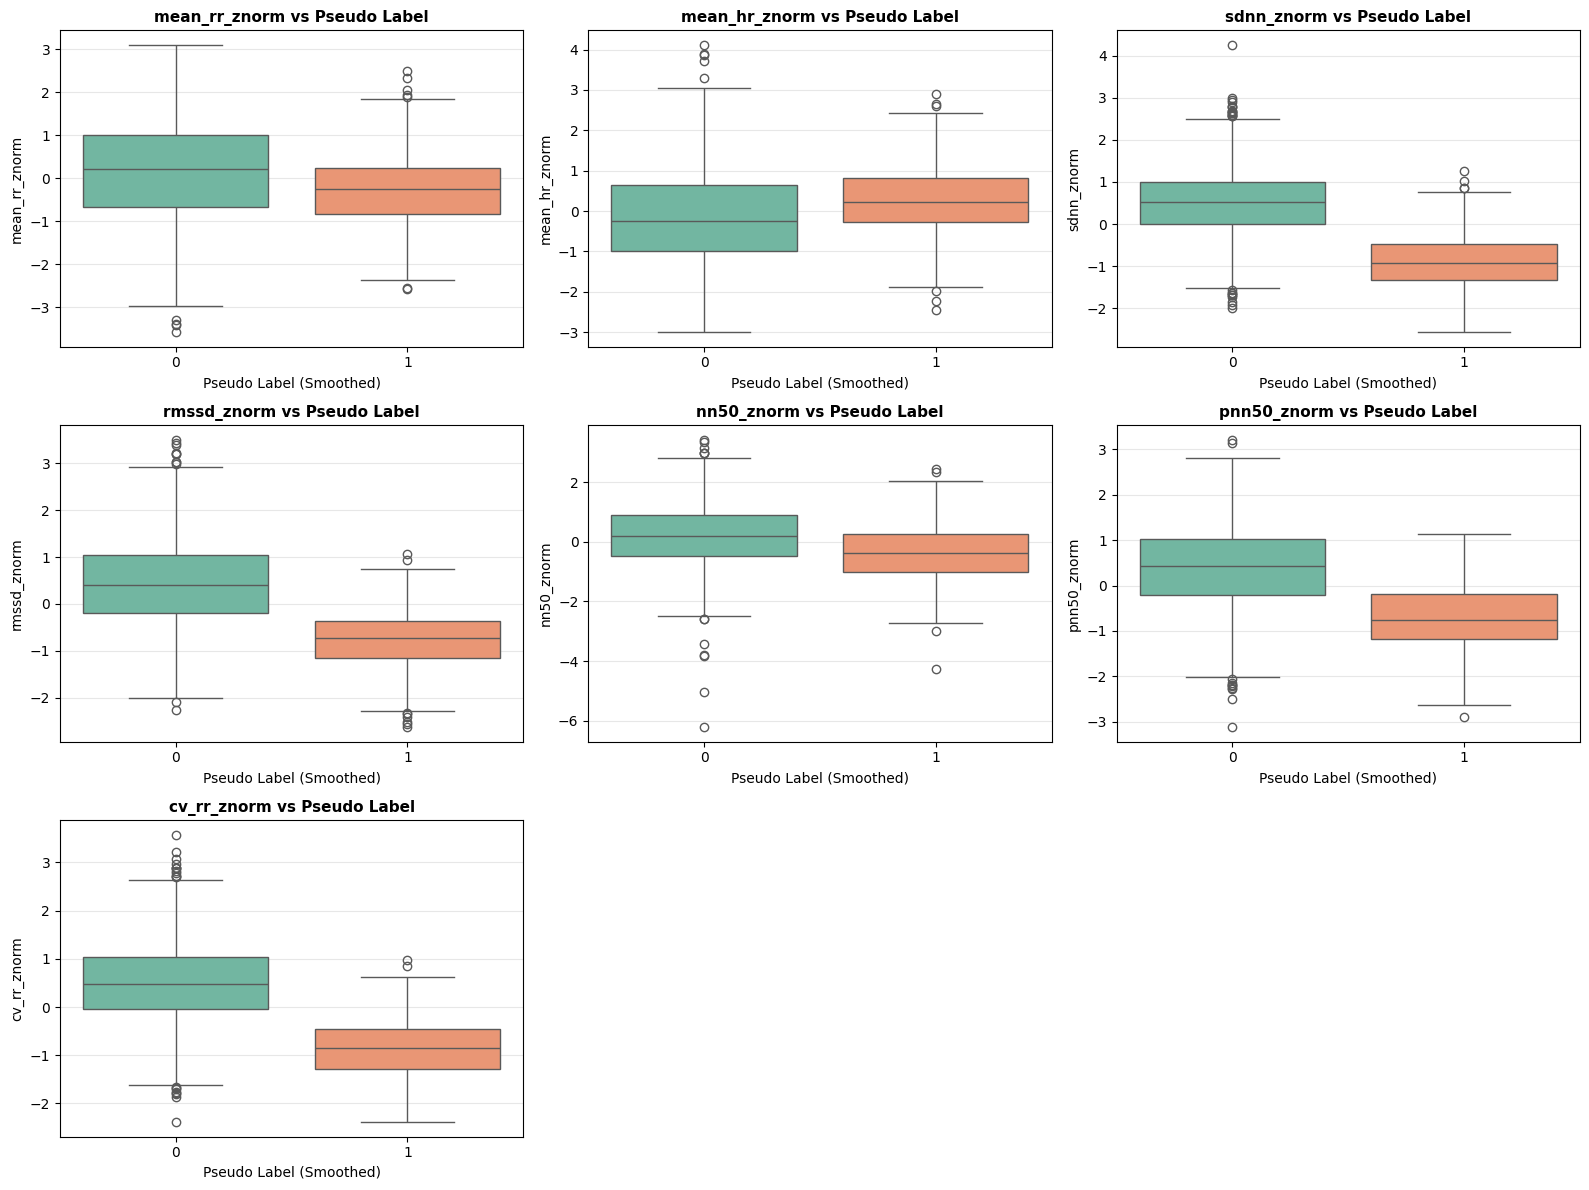

Boxplots generated successfully!


In [23]:
# Create boxplots for each feature against pseudo_label_smoothed
n_features = len(hrv_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for idx, feature in enumerate(hrv_features):
    ax = axes[idx]
    sns.boxplot(data=df, x="pseudo_label_smoothed", y=feature, ax=ax, palette="Set2")
    ax.set_title(f"{feature} vs Pseudo Label", fontweight="bold", fontsize=11)
    ax.set_xlabel("Pseudo Label (Smoothed)", fontsize=10)
    ax.set_ylabel(feature, fontsize=10)
    ax.grid(axis="y", alpha=0.3)

# Remove extra subplots
for idx in range(n_features, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

print("Boxplots generated successfully!")

In [24]:
from scipy.stats import f_oneway

# Analyze feature separability patterns for boxplots
print("=" * 80)
print("PATTERN ANALYSIS: Feature Separability by Pseudo Label")
print("=" * 80)

# Calculate separation quality: F-statistic for each feature

feature_separability = []

for feature in hrv_features:
    # Get groups of values for each pseudo label
    groups = [group[feature].values for name, group in df.groupby("pseudo_label_smoothed")]

    # Only compute if we have variance in groups
    if len(groups) > 1 and all(len(g) > 0 for g in groups):
        f_stat, p_value = f_oneway(*groups)
        feature_separability.append(
            {
                "Feature": feature,
                "F-Statistic": f_stat,
                "P-Value": p_value,
                "Separability": "High"
                if p_value < 0.001
                else ("Medium" if p_value < 0.05 else "Low"),
            }
        )

df_separability = pd.DataFrame(feature_separability).sort_values("F-Statistic", ascending=False)

print("\nFeature Separability Ranking (ordered by F-Statistic):")
print(df_separability.to_string(index=False))

n_high = len(df_separability[df_separability["Separability"] == "High"])
n_med = len(df_separability[df_separability["Separability"] == "Medium"])
n_low = len(df_separability[df_separability["Separability"] == "Low"])
print(f"\n✓ High Separability Features (p < 0.001): {n_high}")
print(f"✓ Medium Separability Features (p < 0.05): {n_med}")
print(f"✓ Low Separability Features (p >= 0.05): {n_low}")

PATTERN ANALYSIS: Feature Separability by Pseudo Label

Feature Separability Ranking (ordered by F-Statistic):
      Feature  F-Statistic       P-Value Separability
   sdnn_znorm  2290.798344  0.000000e+00         High
  cv_rr_znorm  1958.213994  0.000000e+00         High
  rmssd_znorm  1217.074354 3.452827e-218         High
  pnn50_znorm   996.525828 8.531825e-185         High
   nn50_znorm   186.256899  5.616398e-41         High
mean_rr_znorm   105.533551  2.768002e-24         High
mean_hr_znorm    95.640912  3.377705e-22         High

✓ High Separability Features (p < 0.001): 7
✓ Medium Separability Features (p < 0.05): 0
✓ Low Separability Features (p >= 0.05): 0


## Violin plots

C:\Users\moris\AppData\Local\Temp\ipykernel_13304\1973997187.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='pseudo_label_smoothed', y=feature, ax=ax, palette='Set2')
C:\Users\moris\AppData\Local\Temp\ipykernel_13304\1973997187.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='pseudo_label_smoothed', y=feature, ax=ax, palette='Set2')
C:\Users\moris\AppData\Local\Temp\ipykernel_13304\1973997187.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='pseudo_label_smoothed', y=feature, ax=ax, pa

C:\Users\moris\AppData\Local\Temp\ipykernel_13304\1973997187.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='pseudo_label_smoothed', y=feature, ax=ax, palette='Set2')
C:\Users\moris\AppData\Local\Temp\ipykernel_13304\1973997187.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='pseudo_label_smoothed', y=feature, ax=ax, palette='Set2')
C:\Users\moris\AppData\Local\Temp\ipykernel_13304\1973997187.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='pseudo_label_smoothed', y=feature, ax=ax, pa

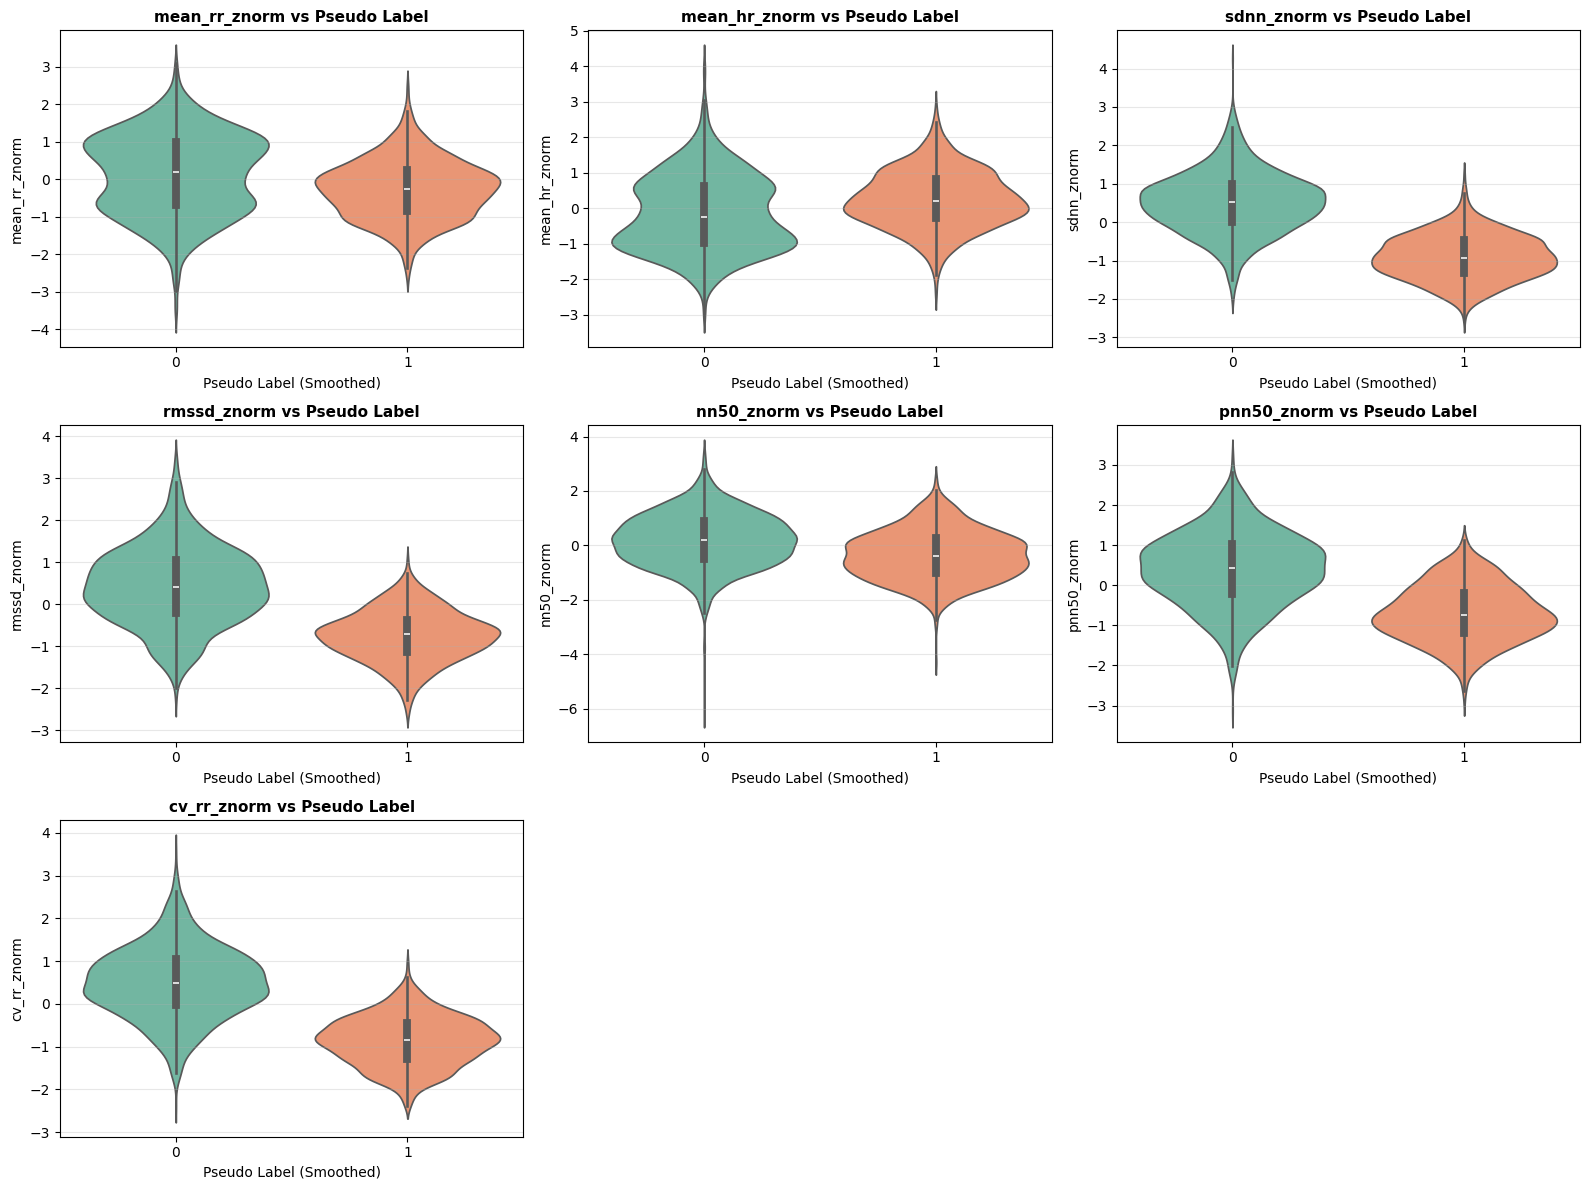

Violin plots generated successfully!


In [25]:
# Create violin plots for each feature against pseudo_label_smoothed
n_features = len(hrv_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for idx, feature in enumerate(hrv_features):
    ax = axes[idx]
    sns.violinplot(data=df, x="pseudo_label_smoothed", y=feature, ax=ax, palette="Set2")
    ax.set_title(f"{feature} vs Pseudo Label", fontweight="bold", fontsize=11)
    ax.set_xlabel("Pseudo Label (Smoothed)", fontsize=10)
    ax.set_ylabel(feature, fontsize=10)
    ax.grid(axis="y", alpha=0.3)

# Remove extra subplots
for idx in range(n_features, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

print("Violin plots generated successfully!")

In [26]:
# Analyze distributional patterns with statistical tests
from scipy.stats import kruskal, levene

print("=" * 80)
print("PATTERN ANALYSIS: Distribution Shapes & Variance Homogeneity")
print("=" * 80)

distribution_patterns = []

for feature in hrv_features:
    # Get groups of values for each pseudo label
    groups = [group[feature].dropna().values for name, group in df.groupby("pseudo_label_smoothed")]

    # Only compute if we have variance in groups
    if len(groups) > 1 and all(len(g) > 0 for g in groups):
        # Kruskal-Wallis test (non-parametric alternative to ANOVA)
        h_stat, h_pval = kruskal(*groups)

        # Levene's test for homogeneity of variance
        lev_stat, lev_pval = levene(*groups)

        # Calculate mean and std by group
        means_by_label = df.groupby("pseudo_label_smoothed")[feature].mean().to_dict()
        stds_by_label = df.groupby("pseudo_label_smoothed")[feature].std().to_dict()

        distribution_patterns.append(
            {
                "Feature": feature,
                "Kruskal-Wallis H": h_stat,
                "KW P-Value": h_pval,
                "Levene Stat": lev_stat,
                "Levene P-Value": lev_pval,
                "Variance Homogeneity": "Equal" if lev_pval > 0.05 else "Unequal",
            }
        )

df_patterns = pd.DataFrame(distribution_patterns).sort_values("KW P-Value")

print("\nDistribution Pattern Analysis (ordered by Kruskal-Wallis p-value):")
print(df_patterns.to_string(index=False))

n_sig = len(df_patterns[df_patterns["KW P-Value"] < 0.001])
n_eq = len(df_patterns[df_patterns["Levene P-Value"] > 0.05])
print(f"\n✓ Features with Significant Distribution Differences (p < 0.001): {n_sig}")
print(f"✓ Features with Equal Variances (Levene p > 0.05): {n_eq}")

print("\n" + "=" * 80)
print("KEY INSIGHTS:")
print("=" * 80)
print("• Features with LOW p-values show CLEAR PATTERNS by pseudo label")
print("• Features with UNEQUAL variance may show non-linear relationships")
print("• Violin plots reveal distribution shape (bimodal, skewed, etc.)")

PATTERN ANALYSIS: Distribution Shapes & Variance Homogeneity

Distribution Pattern Analysis (ordered by Kruskal-Wallis p-value):
      Feature  Kruskal-Wallis H    KW P-Value  Levene Stat  Levene P-Value Variance Homogeneity
   sdnn_znorm       1291.147995 9.481817e-283    65.724972    7.976509e-16              Unequal
  cv_rr_znorm       1202.357904 1.874395e-263   104.717903    4.109864e-24              Unequal
  rmssd_znorm        904.239730 1.175322e-198   162.490748    4.036433e-36              Unequal
  pnn50_znorm        761.246807 1.438682e-167    64.743512    1.296247e-15              Unequal
   nn50_znorm        183.231355  9.548127e-42     3.909927    4.810969e-02              Unequal
mean_hr_znorm        107.593203  3.300150e-25   114.457651    3.699971e-26              Unequal
mean_rr_znorm        107.206497  4.011196e-25   150.601074    1.130340e-33              Unequal

✓ Features with Significant Distribution Differences (p < 0.001): 7
✓ Features with Equal Variances (L

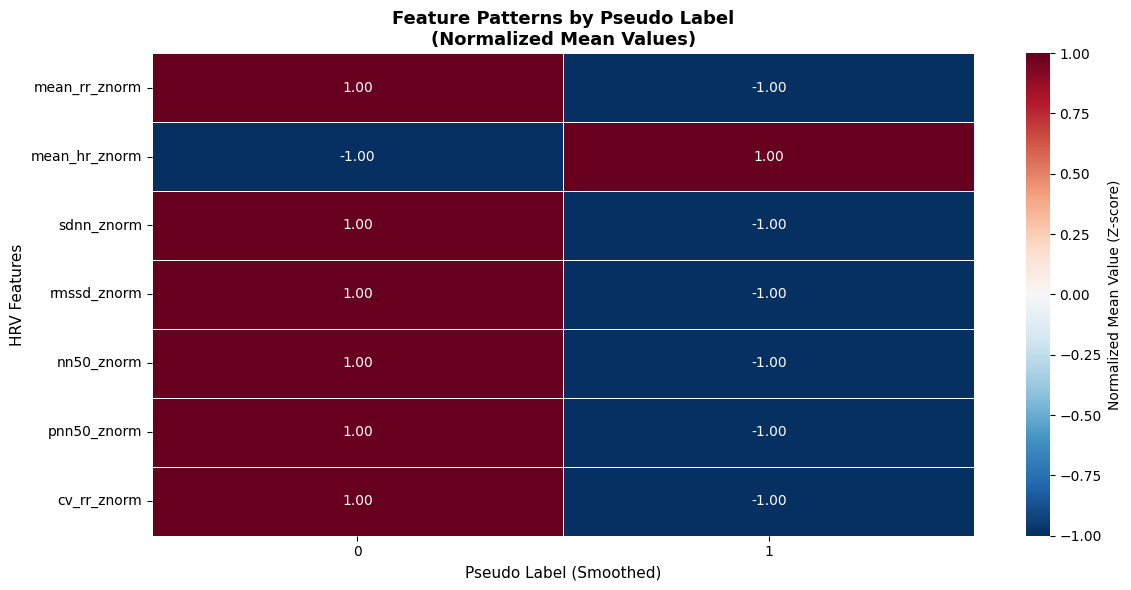

Summary heatmap generated successfully!

Interpretation:
• Red: Features with HIGH values for that pseudo label
• Blue: Features with LOW values for that pseudo label
• Consistent color patterns across columns indicate strong discriminative features


In [27]:
# Create summary heatmap showing mean feature values by pseudo label
from scipy.stats import zscore

# Prepare data for heatmap
heatmap_data = df.groupby("pseudo_label_smoothed")[hrv_features].mean()

# Normalize for better visualization
heatmap_data_normalized = heatmap_data.apply(zscore, nan_policy="omit")

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    heatmap_data_normalized.T,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    cbar_kws={"label": "Normalized Mean Value (Z-score)"},
    ax=ax,
    linewidths=0.5,
)

ax.set_title(
    "Feature Patterns by Pseudo Label\n(Normalized Mean Values)", fontweight="bold", fontsize=13
)
ax.set_xlabel("Pseudo Label (Smoothed)", fontsize=11)
ax.set_ylabel("HRV Features", fontsize=11)
plt.tight_layout()
plt.show()

print("Summary heatmap generated successfully!")
print("\nInterpretation:")
print("• Red: Features with HIGH values for that pseudo label")
print("• Blue: Features with LOW values for that pseudo label")
print("• Consistent color patterns across columns indicate strong discriminative features")